In [1]:
# IMPORTS
import os
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np
import torchvision
from torchvision.transforms import v2
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from tqdm import tqdm

In [2]:
# CONSTANTS
plt.style.use('dark_background')

EXAMPLES_FOR_PLOT = 5
LATENT_SIZE = 64
BATCH_SIZE = 64
EPOCHS = 100
DEVICE = "cpu"

if torch.cuda.is_available():
    DEVICE = "cuda"

LOCAL_DATA_PATH = "../.local_data"
DATASET_PATH = f"{LOCAL_DATA_PATH}/datasets"
WEIGHTS_PATH = f"{LOCAL_DATA_PATH}/model_weights"
LOGS_PATH = f"{LOCAL_DATA_PATH}/logs"
os.makedirs(DATASET_PATH, exist_ok=True)
os.makedirs(WEIGHTS_PATH, exist_ok=True)
os.makedirs(LOGS_PATH, exist_ok=True)

In [3]:
# DATA PREP

os.makedirs(DATASET_PATH, exist_ok=True)
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    # v2.Normalize((0.1307,), (0.3081,)) TODO investigate
])
train_data = torchvision.datasets.MNIST(DATASET_PATH, download=True, transform=transform, train=True)
test_data = torchvision.datasets.MNIST(DATASET_PATH, download=True, transform=transform, train=False)

train_dataloader = DataLoader(train_data, BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_data, BATCH_SIZE, shuffle=False)

# getting EXAMPLES_FOR_PLOT examples for plotting, TODO rewrite
examples = None
for X, _ in test_dataloader:
    examples = X[:EXAMPLES_FOR_PLOT, :].to(DEVICE)
    break

In [4]:
# MODEL

class VAE(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()

        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),  # 28 -> 14
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # 14 -> 7
            nn.ReLU(inplace=True),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 256),
            nn.ReLU(inplace=True),
        )

        self.mu_head = nn.Linear(256, latent_dim)
        self.std_head = nn.Linear(256, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128 * 7 * 7),
            nn.ReLU(inplace=True),
            nn.Unflatten(1, (128, 7, 7)),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # 7 -> 14
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1),  # 14 -> 28
            nn.Sigmoid(),
        )

    def encode(self, x):
        """Encode input into mean and standard deviation."""
        h = self.encoder(x)
        mu = self.mu_head(h)
        std = self.std_head(h)
        return mu, std

    def reparameterize(self, mu, std):
        """Reparameterization trick: sample z = mu + std * eps."""
        eps = torch.randn_like(std)          # device‑agnostic, same shape as std
        return mu + eps * std

    def decode(self, z):
        """Decode latent vector into reconstructed image."""
        return self.decoder(z)

    def forward(self, x):
        mu, std = self.encode(x)
        z = self.reparameterize(mu, std)
        recon = self.decode(z)
        return recon, mu, std

class ELBOLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, y, y_prim, mu, std):
        # kl = torch.mean(-0.5 * torch.sum(1 + torch.log(std**2) - mu**2 - std**2, dim=1))

        mse_loss = F.mse_loss(y, y_prim)
        kld_loss = torch.mean(-0.5 * torch.sum(1 + std - mu ** 2 - std.exp(), dim=1), dim=0)
        kld_weight = 1

        # kld_loss = torch.mean(-0.5 * torch.sum(1 + log_var - mu ** 2 - log_var.exp(), dim = 1), dim = 0)

        loss = mse_loss + kld_weight * kld_loss
        return mse_loss, kld_loss

100%|██████████| 157/157 [00:05<00:00, 30.17it/s]


--------- ITERATION 1 ---------
train loss: 0.028945022483052474
train kl: 0.0018792591997976306
train l2: 0.027065763183470284

test loss: 0.01113081153980486
test kl: 0.0012865322879307968
test l2: 0.009844279290432004


<Figure size 640x480 with 0 Axes>

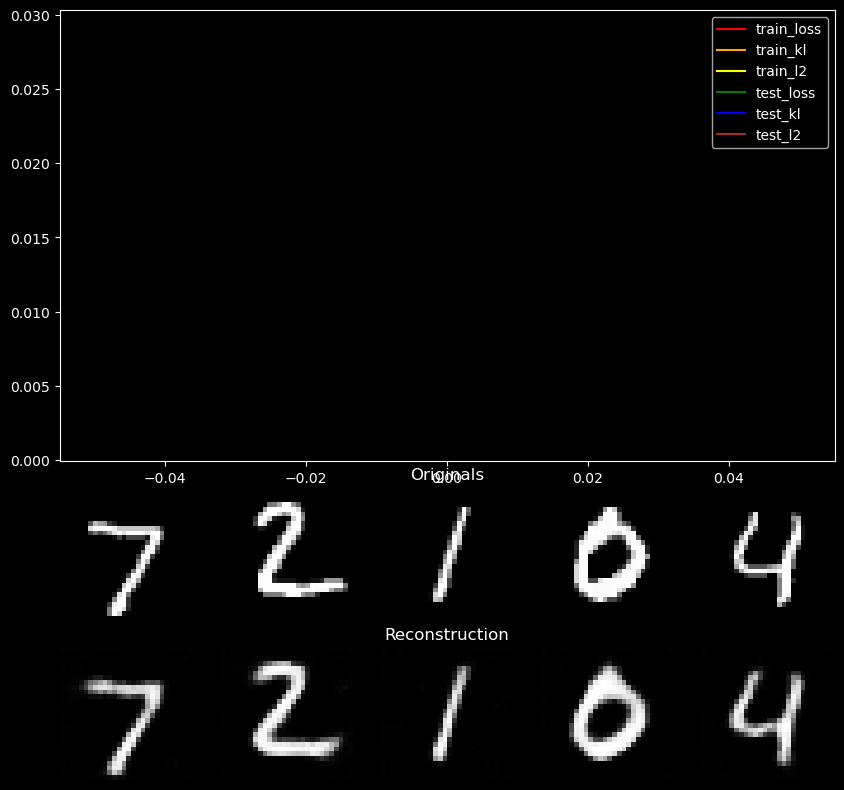

100%|██████████| 157/157 [00:05<00:00, 30.84it/s]

--------- ITERATION 2 ---------
train loss: 0.009387950992771685
train kl: 0.0010652705914835367
train l2: 0.008322680409231197

test loss: 0.007903212017029714
test kl: 0.0009058360870524197
test l2: 0.006997375947773267


<Figure size 640x480 with 0 Axes>

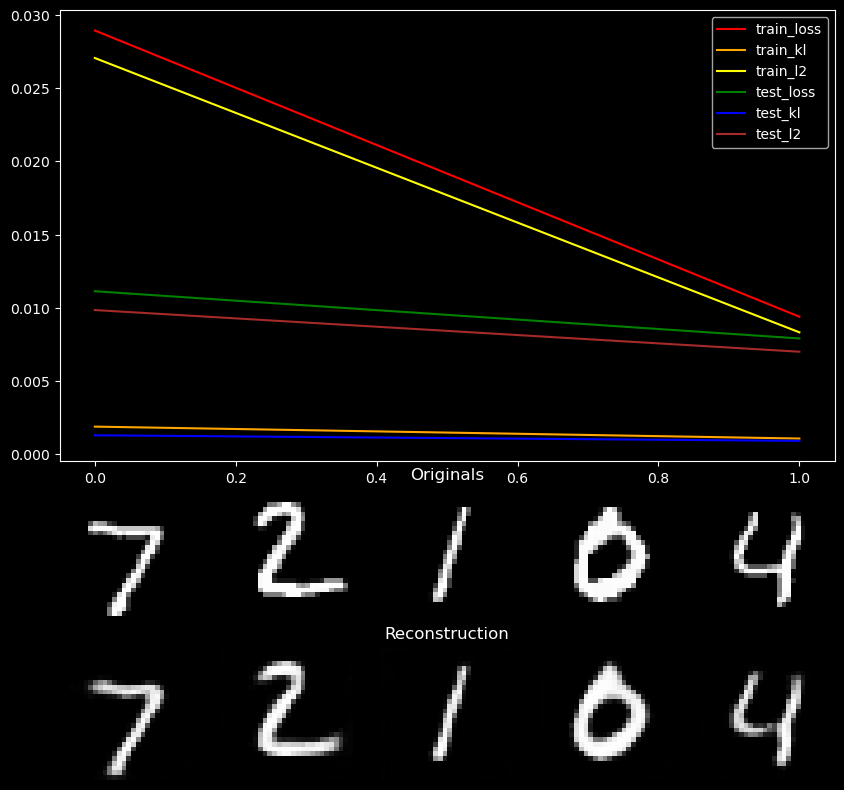

100%|██████████| 157/157 [00:07<00:00, 20.22it/s]


--------- ITERATION 3 ---------
train loss: 0.007310270630160787
train kl: 0.000843560706867751
train l2: 0.006466709926768121

test loss: 0.007066819529126214
test kl: 0.0007885713041255808
test l2: 0.006278248239830611


<Figure size 640x480 with 0 Axes>

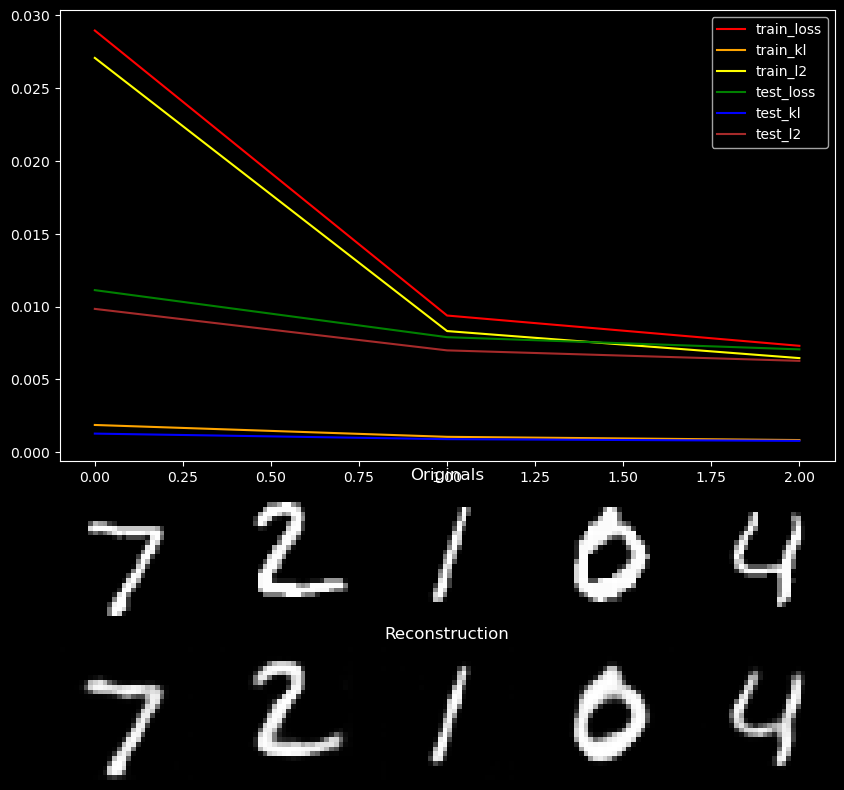

100%|██████████| 157/157 [00:05<00:00, 27.04it/s]


--------- ITERATION 4 ---------
train loss: 0.006325211975155577
train kl: 0.0007259379019901188
train l2: 0.0055992740731654585

test loss: 0.006052547938243788
test kl: 0.0007296170813927225
test l2: 0.005322930858334064


<Figure size 640x480 with 0 Axes>

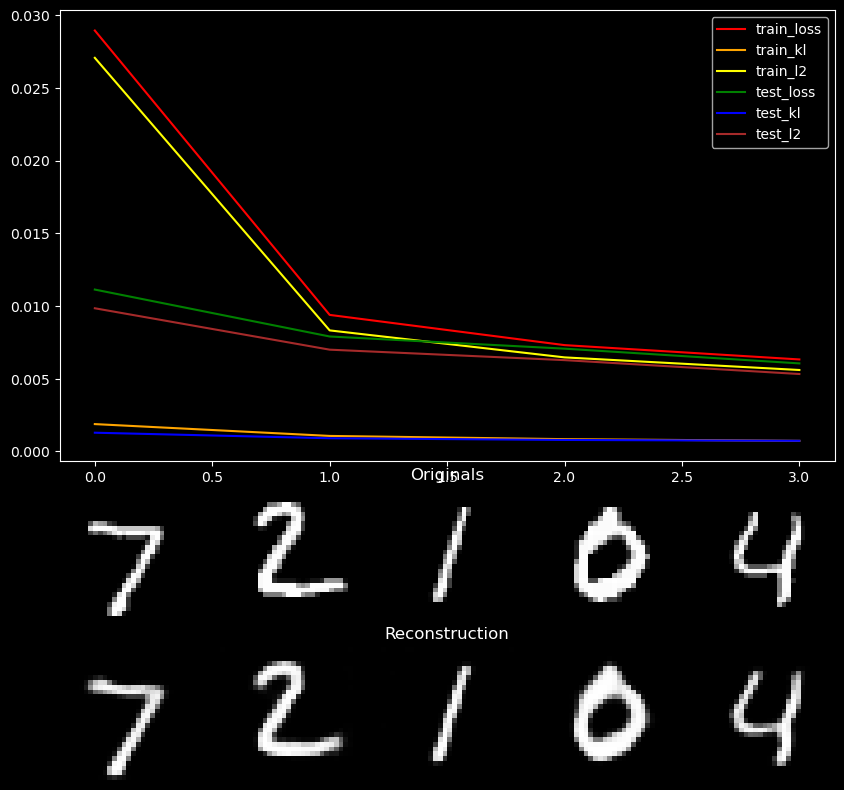

100%|██████████| 157/157 [00:04<00:00, 31.57it/s]


--------- ITERATION 5 ---------
train loss: 0.005764414143285899
train kl: 0.0006572652254690493
train l2: 0.005107148917816849

test loss: 0.005992146217780318
test kl: 0.000616635237434867
test l2: 0.0053755109803454515


<Figure size 640x480 with 0 Axes>

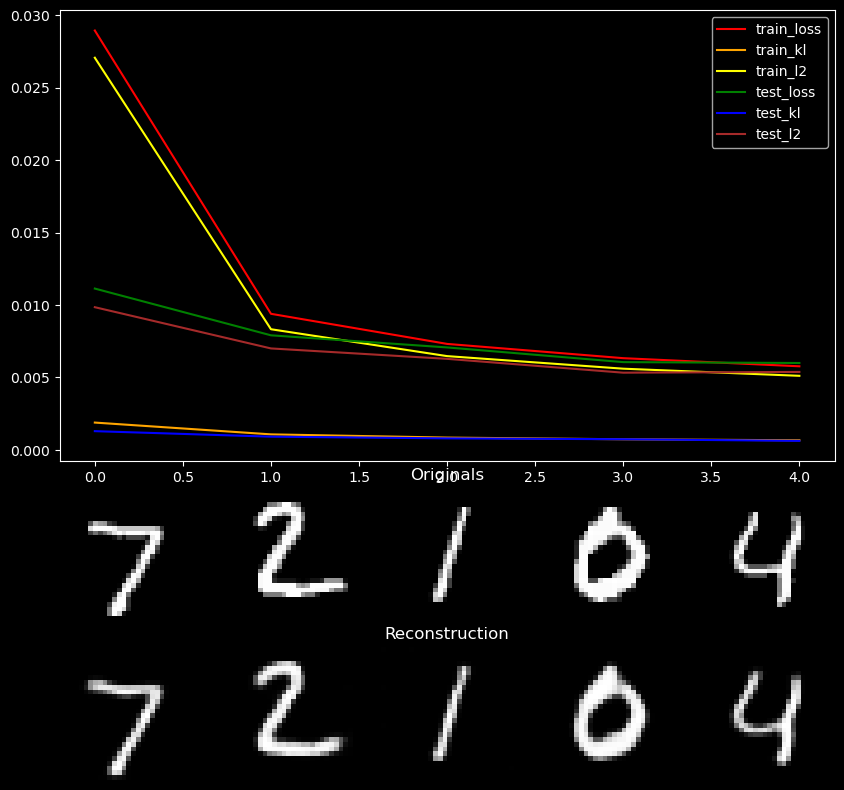

100%|██████████| 157/157 [00:04<00:00, 32.87it/s]


--------- ITERATION 6 ---------
train loss: 0.0053078760025597835
train kl: 0.0006088105180282901
train l2: 0.004699065483786833

test loss: 0.005347685805361741
test kl: 0.0006091813082290683
test l2: 0.004738504497132674


<Figure size 640x480 with 0 Axes>

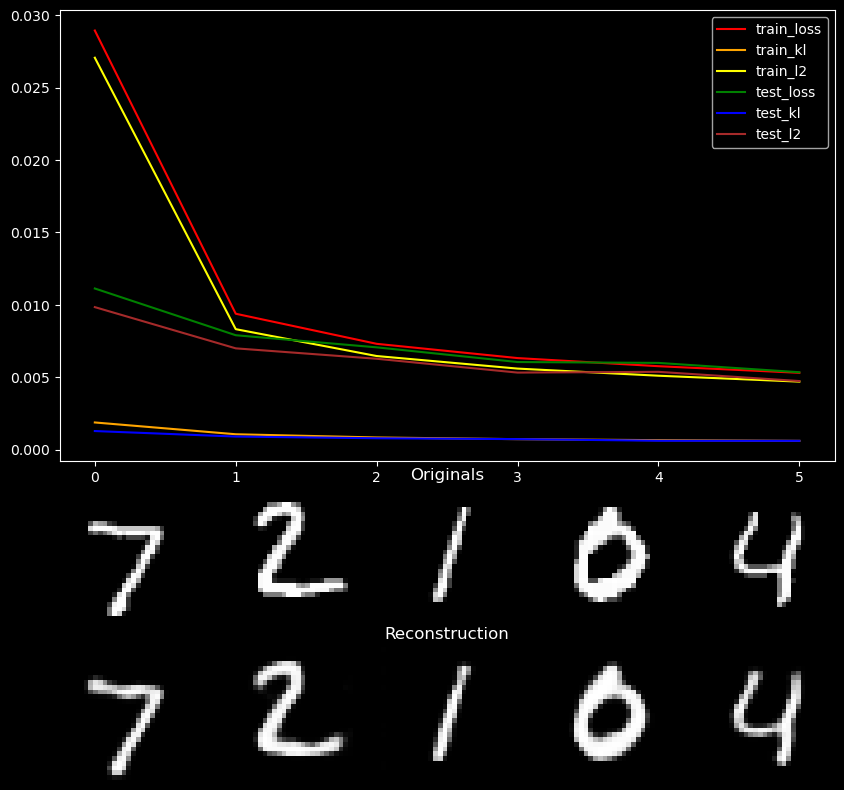

100%|██████████| 157/157 [00:04<00:00, 37.71it/s]


--------- ITERATION 7 ---------
train loss: 0.004959806575001017
train kl: 0.0005712630033596302
train l2: 0.004388543571144946

test loss: 0.004856645119240045
test kl: 0.0005496994971896812
test l2: 0.004306945623533362


<Figure size 640x480 with 0 Axes>

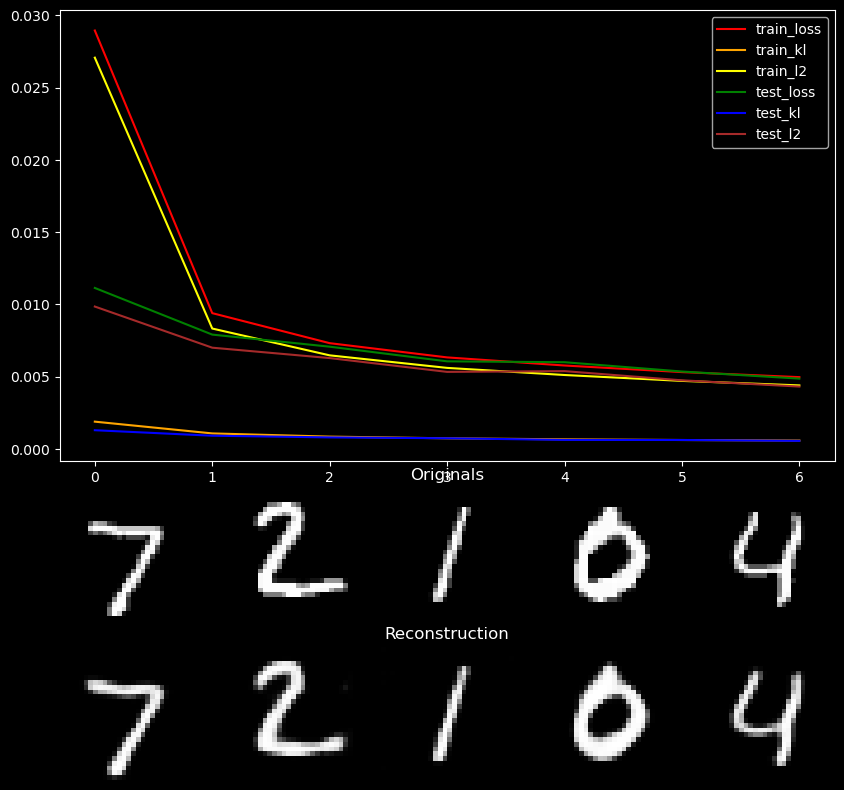

100%|██████████| 157/157 [00:04<00:00, 38.20it/s]


--------- ITERATION 8 ---------
train loss: 0.004665062293164067
train kl: 0.0005359805123542926
train l2: 0.004129081780313334

test loss: 0.004460641648620367
test kl: 0.0004934731775977809
test l2: 0.0039671684769545775


<Figure size 640x480 with 0 Axes>

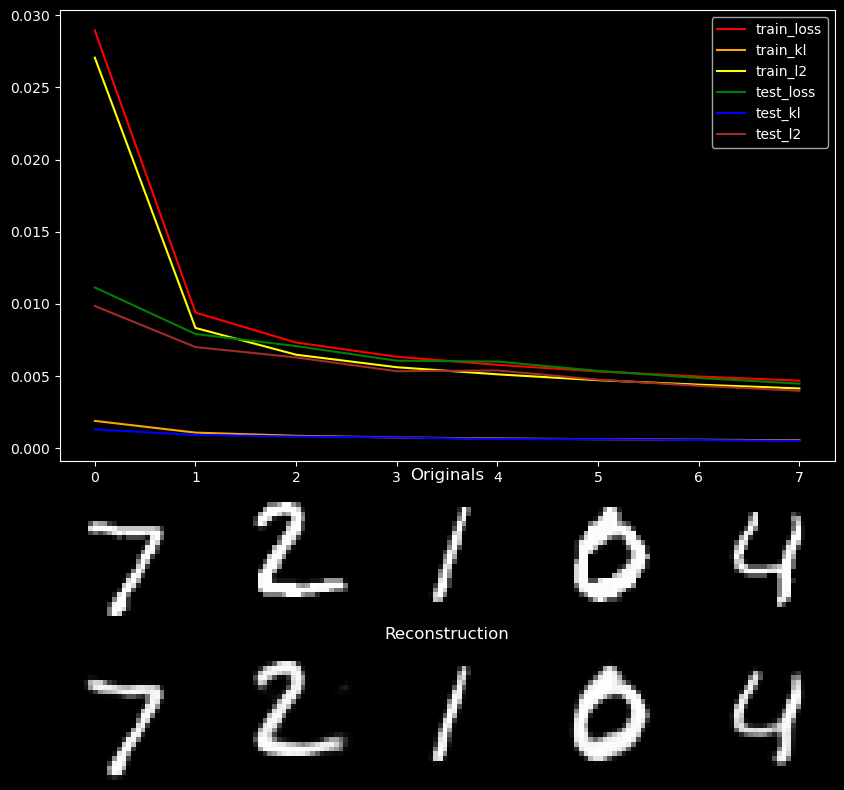

100%|██████████| 157/157 [00:04<00:00, 32.31it/s]


--------- ITERATION 9 ---------
train loss: 0.004434014785476823
train kl: 0.0005086886106746029
train l2: 0.003925326175050441

test loss: 0.00439757218133587
test kl: 0.000443686698533737
test l2: 0.003953885476870142


<Figure size 640x480 with 0 Axes>

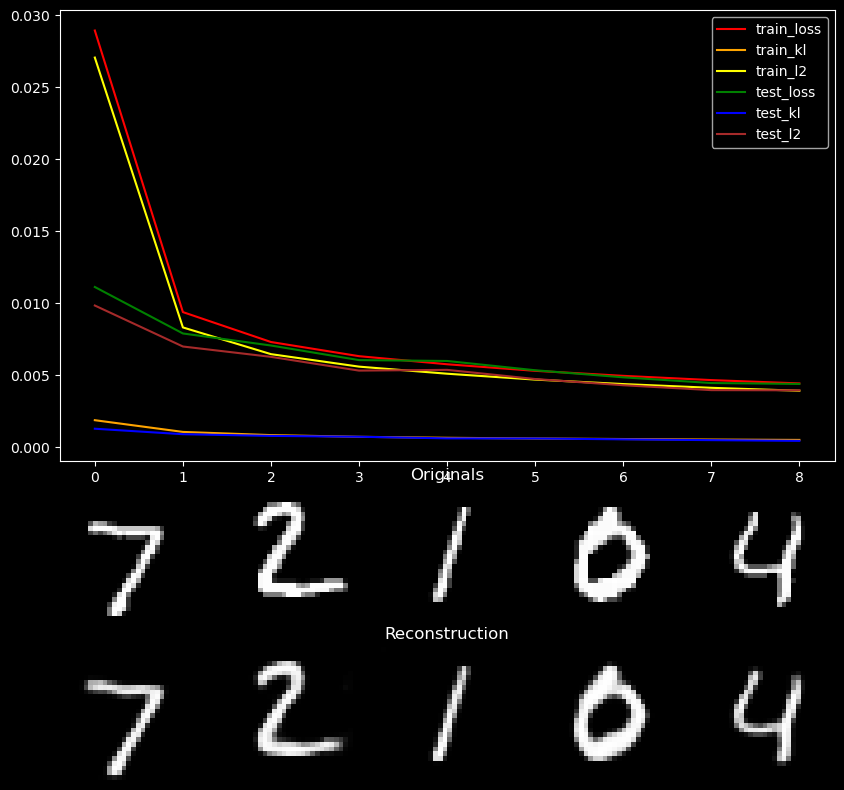

100%|██████████| 157/157 [00:10<00:00, 15.19it/s]


--------- ITERATION 10 ---------
train loss: 0.0042463501340457436
train kl: 0.00048425441671377307
train l2: 0.0037620957118711237

test loss: 0.004348954756797594
test kl: 0.0004914896740655231
test l2: 0.003857465093113055


<Figure size 640x480 with 0 Axes>

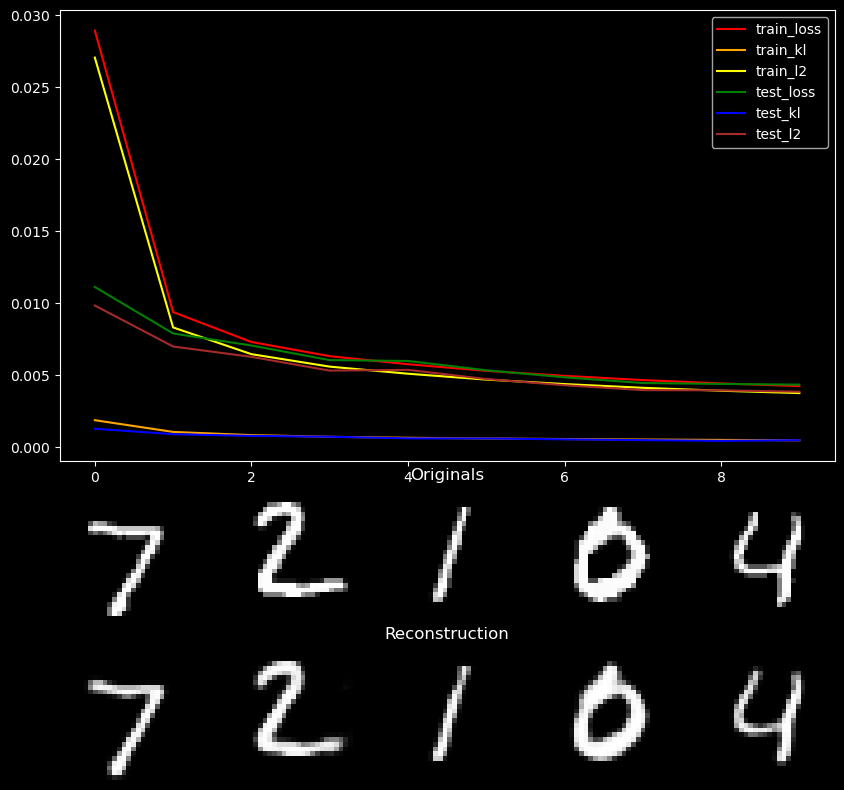

100%|██████████| 157/157 [00:03<00:00, 40.39it/s]


--------- ITERATION 11 ---------
train loss: 0.00414562660546453
train kl: 0.00048255393736318613
train l2: 0.003663072668349565

test loss: 0.004465673449538221
test kl: 0.00047907402299961465
test l2: 0.003986599426538606


<Figure size 640x480 with 0 Axes>

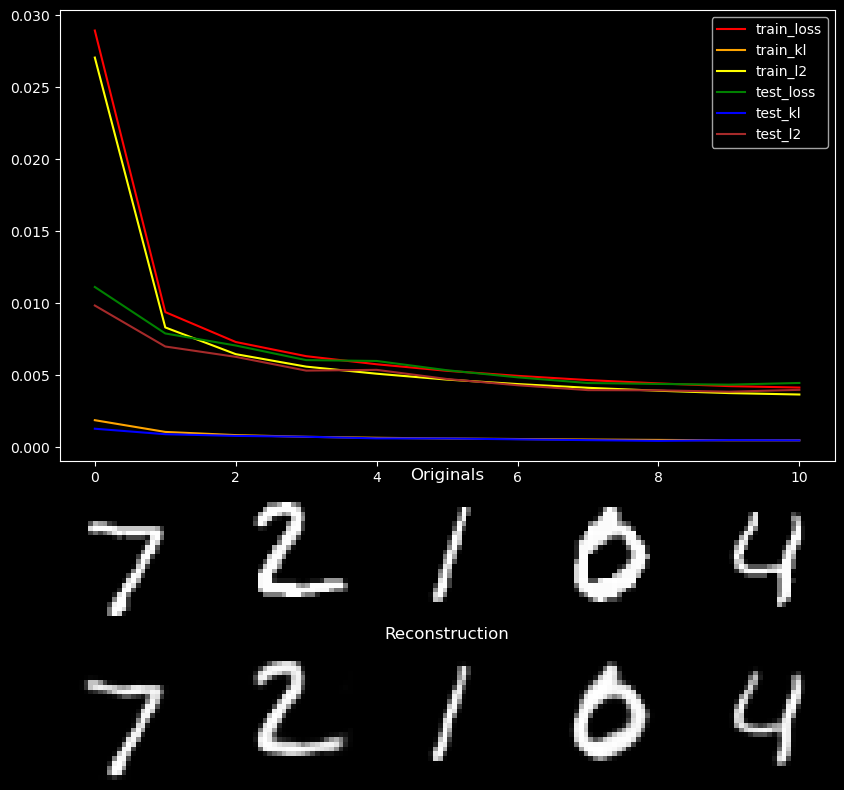

 16%|█▌        | 150/938 [00:07<00:40, 19.64it/s]


KeyboardInterrupt: 

In [5]:
# TRAIN LOOP

model = VAE(LATENT_SIZE).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters())
loss_fn = ELBOLoss()

metrics = defaultdict(list)
# train_l2, train_kl, train_loss
# test_l2, test_kl, test_loss

for epoch in range(1, EPOCHS):
    metrics_epoch = defaultdict(list)

    # train
    model.train()
    for X, _ in tqdm(train_dataloader):
        X = X.to(DEVICE)
        X_prim, mu, std = model.forward(X)
        l2, kl = loss_fn(X, X_prim, mu, std)
        loss = l2 + kl

        loss.backward()
        optimizer.step()
        model.zero_grad()

        # save losses
        metrics_epoch["train_l2"].append(l2.item())
        metrics_epoch["train_kl"].append(kl.item())
        metrics_epoch["train_loss"].append(loss.item())

    # test
    model.eval()
    with torch.no_grad():
        for X, _ in tqdm(test_dataloader):
            X = X.to(DEVICE)
            X_prim, mu, std = model.forward(X)

            l2, kl = loss_fn(X, X_prim, mu, std)
            loss = l2 + kl

            # save losses
            metrics_epoch["test_l2"].append(l2.item())
            metrics_epoch["test_kl"].append(kl.item())
            metrics_epoch["test_loss"].append(loss.item())

    # update metrics dict
    for key, value in metrics_epoch.items():
        mean_value = np.mean(value)
        metrics[key].append(mean_value)

    print(f"--------- ITERATION {epoch} ---------")
    print(f"train loss: {metrics["train_loss"][-1]}")
    print(f"train kl: {metrics["train_kl"][-1]}")
    print(f"train l2: {metrics["train_l2"][-1]}")
    print()
    print(f"test loss: {metrics["test_loss"][-1]}")
    print(f"test kl: {metrics["test_kl"][-1]}")
    print(f"test l2: {metrics["test_l2"][-1]}")

    # plot
    plt.clf()
    x = list(range(epoch))

    fig = plt.figure(figsize=(10, 10))
    gs = GridSpec(5, 5)

    # losses graph
    plt.subplot(gs[0:3, :])
    plt.plot(x, metrics["train_loss"], color="red", label="train_loss")
    plt.plot(x, metrics["train_kl"], color="orange", label="train_kl")
    plt.plot(x, metrics["train_l2"], color="yellow", label="train_l2")

    plt.plot(x, metrics["test_loss"], color="green", label="test_loss")
    plt.plot(x, metrics["test_kl"], color="blue", label="test_kl")
    plt.plot(x, metrics["test_l2"], color="brown", label="test_l2")

    plt.legend()

    # images examples
    examples_prim, _, _ = model.forward(examples)
    for i in range(EXAMPLES_FOR_PLOT):
        ex = examples[i, :].cpu().squeeze().detach().numpy()
        ex_prim = examples_prim[i, :].cpu().squeeze().detach().numpy()
        plt.subplot(gs[3, i])
        plt.axis("off")
        plt.imshow(ex, cmap="gray")
        plt.subplot(gs[4, i])
        plt.axis("off")
        plt.imshow(ex_prim, cmap="gray")

    # titles for examples
    plt.subplot(gs[3, :])
    plt.axis("off")
    plt.title("Originals")
    plt.subplot(gs[4, :])
    plt.axis("off")
    plt.title("Reconstruction")

    if epoch % 5 == 0:
        plt.savefig(f"{LOGS_PATH}/vae_mnist_training.png")
        torch.save(model.state_dict(), f"{WEIGHTS_PATH}/vae_mnist.pt")

    plt.show()